# Benchmarking de Algoritmos: Regresión vs. Clasificación
## Predicción de Intención de Compra — *E-commerce Shopper Intention*

**Dataset:** `ecommerce_shopper_intention.csv` (UCI ML Repository — Sakar et al., 2019)
**Variable objetivo:** `Revenue` (¿la sesión terminó en compra? `True`/`False`)

---

### Contexto de negocio

Marketing necesita entender **por qué** compra un cliente y, a la vez, maximizar la **precisión predictiva** para decidir a qué sesiones vale la pena mostrarles un incentivo. Por eso comparamos dos modelos:

| Modelo | Rol |
|---|---|
| **Regresión Logística** | Interpretable — sus coeficientes explican el comportamiento del cliente |
| **Random Forest** | Caja negra — maximiza el poder predictivo |

**Entregable final:** conclusión ejecutiva que responde qué modelo recomendamos y qué variable influye más en la compra.


## 1. Configuración del entorno

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 2. Carga y exploración inicial de los datos

Dataset con **12,330 sesiones** de un sitio e-commerce: atributos de navegación (páginas visitadas, duración, tasa de rebote, etc.) y la variable objetivo `Revenue`.


In [2]:
# Carga de datos: local primero, URL de respaldo si no existe
import os

RUTA_LOCAL = "ecommerce_shopper_intention.csv"
URL_RESPALDO = (
    "https://raw.githubusercontent.com/Camille-Le-Roy/"
    "data_analytics_resources/main/"
    "Module_02_machine_learning_and_feature_engineering/"
    "datasets/online_shoppers_intention.csv"
)

if os.path.exists(RUTA_LOCAL):
    df = pd.read_csv(RUTA_LOCAL)
else:
    df = pd.read_csv(URL_RESPALDO)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Filas: 12,330 | Columnas: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [4]:
# Nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")
print(f"Filas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
0 valores nulos en total
Filas duplicadas: 125


**Observación:** no hay valores nulos. Hay algunas filas duplicadas (sesiones con el mismo patrón de navegación), normales en datos de comportamiento web, así que se dejan intactas.


## 3. Distribución de la variable objetivo (`Revenue`)

Revisamos el balance de clases: determina la estrategia de split y la métrica de evaluación correcta.


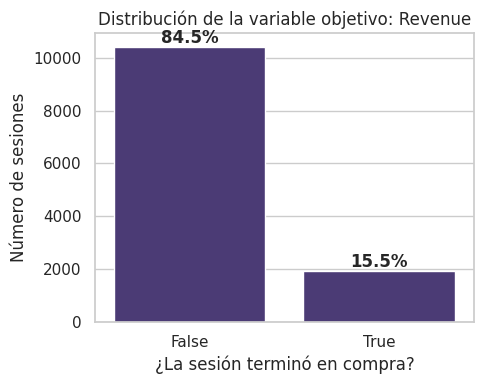

Revenue
False    84.53
True     15.47
Name: proportion, dtype: float64


In [5]:
conteo_abs = df["Revenue"].value_counts().reindex([False, True])
conteo_pct = df["Revenue"].value_counts(normalize=True).reindex(
    [False, True]
) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Revenue", data=df, order=[False, True], ax=ax)
for i, (abs_val, pct) in enumerate(zip(conteo_abs, conteo_pct)):
    ax.text(i, abs_val + 150, f"{pct:.1f}%", ha="center", fontweight="bold")
ax.set_title("Distribución de la variable objetivo: Revenue")
ax.set_xlabel("¿La sesión terminó en compra?")
ax.set_ylabel("Número de sesiones")
plt.tight_layout()
plt.show()

print(conteo_pct.round(2))


**Hallazgo clave:** el dataset está **desbalanceado** — solo ~15.5% de las sesiones terminan en compra. Por eso usamos `stratify=y` en el split y `class_weight="balanced"` en los modelos.


## 4. Train/Test Split — previniendo Data Leakage

**Regla de oro:** el test set no debe influir en el entrenamiento. Por eso:

1. Separamos `X` e `y` antes de cualquier transformación.
2. Hacemos el `train_test_split` antes de ajustar escalador, encoder o modelo.
3. El preprocesamiento va dentro de un `Pipeline`, así el `.fit()` solo ve el train; el test solo se transforma.

Si escaláramos o codificáramos con el dataset completo antes de partirlo, el modelo "vería" estadísticas del test durante el entrenamiento — eso es **Data Leakage**, e infla el desempeño reportado.


In [6]:
X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

# Códigos numéricos que en realidad son categorías (SO, navegador, región, tráfico)
categorical_cols = [
    "Month", "VisitorType", "Weekend",
    "OperatingSystems", "Browser", "Region", "TrafficType",
]
numerical_cols = [c for c in X.columns if c not in categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Proporción de compra en train: {y_train.mean():.4f}")
print(f"Proporción de compra en test:  {y_test.mean():.4f}")


Train: 9,864 filas | Test: 2,466 filas
Proporción de compra en train: 0.1547
Proporción de compra en test:  0.1549


El `stratify=y` mantiene la misma proporción de compradores (~15.5%) en train y test.


## 5. Pipeline de preprocesamiento

`ColumnTransformer` aplica `OneHotEncoder` a las categóricas y `StandardScaler` a las numéricas. Al envolverlo en un `Pipeline` con el modelo, `.fit()` solo ve datos de entrenamiento — la forma estándar de evitar leakage.


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols),
    ]
)


## 6. Duelo de modelos

### 6.1 Modelo interpretable — Regresión Logística


In [8]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

log_reg.fit(X_train, y_train)
print("Regresión Logística entrenada.")


Regresión Logística entrenada.


### 6.2 Modelo de caja negra — Random Forest

In [9]:
random_forest = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

random_forest.fit(X_train, y_train)
print("Random Forest entrenado.")


Random Forest entrenado.


## 7. ¿Por qué el Accuracy no es suficiente aquí?

Construimos un **baseline** que siempre predice la clase mayoritaria ("no compra"), para comprobar si nuestros modelos aportan valor real.


In [10]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(f"Accuracy del baseline (siempre predice 'no compra'): "
      f"{accuracy_score(y_test, baseline_pred):.2%}")
print(f"Recall del baseline sobre compradores reales: "
      f"{recall_score(y_test, baseline_pred):.2%}")


Accuracy del baseline (siempre predice 'no compra'): 84.51%
Recall del baseline sobre compradores reales: 0.00%


**El problema:** un modelo que nunca detecta un comprador real ya tiene ~84–85% de Accuracy, porque la clase "no compra" domina el dataset. Lo que importa es **encontrar compradores reales** (Recall) sin generar **demasiadas falsas alarmas** (Precision) — de ahí la Matriz de Confusión.


## 8. Matriz de Confusión, Precision y Recall

Función reutilizable (DRY) para evaluar ambos modelos de forma consistente.


In [11]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    '''Calcula e imprime las métricas clave de clasificación binaria.'''
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }

    print(f"\n{'=' * 55}\n {nombre}\n{'=' * 55}")
    print(classification_report(
        y_test, y_pred, target_names=["No compra", "Compra"]
    ))
    return metrics, y_pred, y_proba


resultados = []
metrics_lr, pred_lr, proba_lr = evaluar_modelo(
    "Regresión Logística", log_reg, X_test, y_test
)
metrics_rf, pred_rf, proba_rf = evaluar_modelo(
    "Random Forest", random_forest, X_test, y_test
)
resultados.extend([metrics_lr, metrics_rf])

tabla_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
tabla_resultados



 Regresión Logística
              precision    recall  f1-score   support

   No compra       0.95      0.86      0.90      2084
      Compra       0.49      0.74      0.59       382

    accuracy                           0.84      2466
   macro avg       0.72      0.80      0.75      2466
weighted avg       0.88      0.84      0.85      2466




 Random Forest
              precision    recall  f1-score   support

   No compra       0.91      0.97      0.94      2084
      Compra       0.75      0.45      0.56       382

    accuracy                           0.89      2466
   macro avg       0.83      0.71      0.75      2466
weighted avg       0.88      0.89      0.88      2466



,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regresión Logística,0.8410,0.4913,0.7435,0.5917,0.8932
Random Forest,0.8917,0.7489,0.4529,0.5644,0.9191


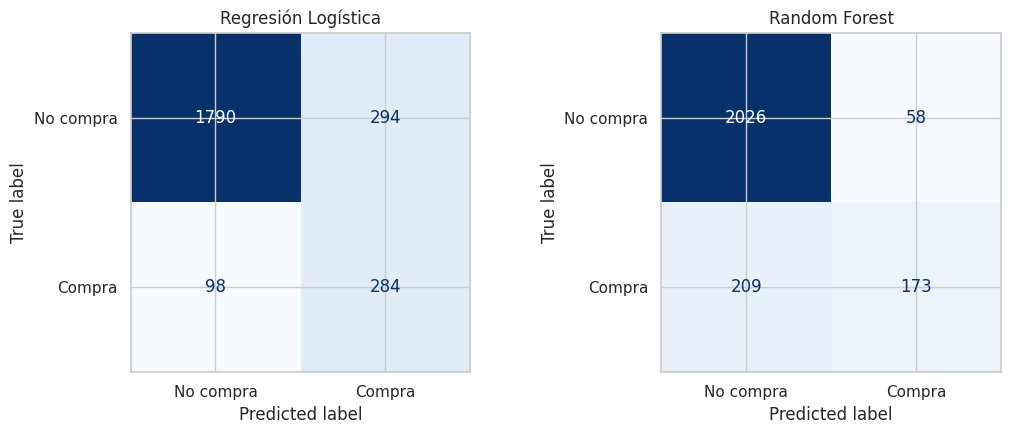

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, nombre, y_pred in zip(
    axes, ["Regresión Logística", "Random Forest"], [pred_lr, pred_rf]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["No compra", "Compra"]
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(nombre)

plt.tight_layout()
plt.show()


### Interpretación de las matrices de confusión

| | Predicho: No compra | Predicho: Compra |
|---|---|---|
| **Real: No compra** | TN | **FP** → descuento innecesario |
| **Real: Compra** | **FN** → venta en riesgo, sin incentivo | TP |

- **Regresión Logística:** identifica **284 de 382** compradores reales (Recall ≈ 74%), pero genera **294 falsas alarmas** (Precision ≈ 49%).
- **Random Forest:** solo **58 falsas alarmas** (Precision ≈ 75%), pero deja sin detectar a **209 de 382** compradores reales (Recall ≈ 45%).

Trade-off clásico Precision–Recall: ninguna métrica por sí sola cuenta la historia completa — hay que traducirlo a costo de negocio.


## 9. Curva ROC: poder de discriminación global

Comparamos qué tan bien cada modelo ordena a los clientes por probabilidad de compra, sin importar el umbral.


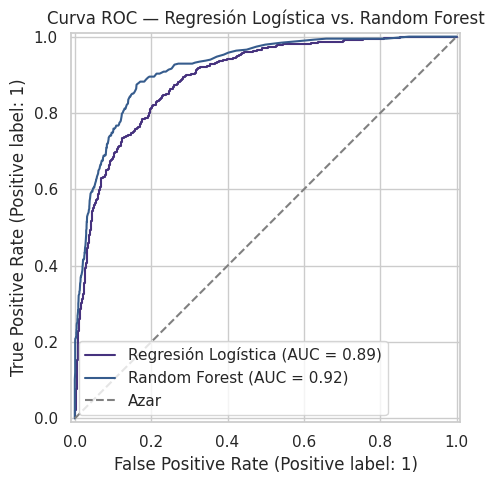

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, proba_lr, name="Regresión Logística", ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, proba_rf, name="Random Forest", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC — Regresión Logística vs. Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


Random Forest tiene **ROC-AUC ligeramente superior**, lo que sugiere que ajustando su umbral podría igualar el Recall de la Regresión Logística sin sacrificar tanta Precision. Lo comprobamos:


In [14]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test, proba_rf
)

recall_objetivo = metrics_lr["Recall"]  # igualar el recall de LogReg
idx = np.argmin(np.abs(recall_curve[:-1] - recall_objetivo))
umbral_ajustado = thresholds[idx]

pred_rf_ajustado = (proba_rf >= umbral_ajustado).astype(int)

print(f"Umbral ajustado de Random Forest: {umbral_ajustado:.3f} "
      f"(en vez del 0.5 por defecto)")
print(f"Recall de Random Forest a este umbral:    "
      f"{recall_score(y_test, pred_rf_ajustado):.2%}")
print(f"Precision de Random Forest a este umbral: "
      f"{precision_score(y_test, pred_rf_ajustado):.2%}")
print(f"(vs. Precision de Regresión Logística:    "
      f"{metrics_lr['Precision']:.2%} al mismo nivel de Recall)")


Umbral ajustado de Random Forest: 0.270 (en vez del 0.5 por defecto)
Recall de Random Forest a este umbral:    74.08%
Precision de Random Forest a este umbral: 58.84%
(vs. Precision de Regresión Logística:    49.13% al mismo nivel de Recall)


**Hallazgo:** al igualar el Recall (~74%), Random Forest logra mayor Precision que la Regresión Logística. Su Recall bajo en la Sección 8 se debía al umbral por defecto (0.5), no a que el modelo sea peor.


## 10. Traduciendo las métricas a impacto financiero

Asignamos un costo a cada tipo de error, asumiendo que el modelo decide si mostrar un incentivo:

- **Falso Positivo:** incentivo regalado sin venta → **$5 USD**.
- **Falso Negativo:** venta perdida sin incentivo → **$45 USD**.

*(Valores ilustrativos; en e-commerce, perder una venta suele costar varias veces más que un descuento desperdiciado.)*


In [15]:
COSTO_FP = 5    # USD — descuento regalado sin conversión
COSTO_FN = 45   # USD — margen de una venta perdida


def costo_negocio(y_true, y_pred, costo_fp=COSTO_FP, costo_fn=COSTO_FN):
    '''Traduce una matriz de confusión a costo total estimado en USD.'''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    costo_total = fp * costo_fp + fn * costo_fn
    return {
        "FP": int(fp), "FN": int(fn),
        "Costo FP ($)": fp * costo_fp,
        "Costo FN ($)": fn * costo_fn,
        "Costo total ($)": costo_total,
    }


comparativo_costos = pd.DataFrame({
    "Regresión Logística": costo_negocio(y_test, pred_lr),
    "Random Forest (umbral 0.5)": costo_negocio(y_test, pred_rf),
    "Random Forest (umbral ajustado)": costo_negocio(y_test, pred_rf_ajustado),
}).T

comparativo_costos


,FP,FN,Costo FP ($),Costo FN ($),Costo total ($)
Regresión Logística,294,98,1470,4410,5880
Random Forest (umbral 0.5),58,209,290,9405,9695
Random Forest (umbral ajustado),198,99,990,4455,5445


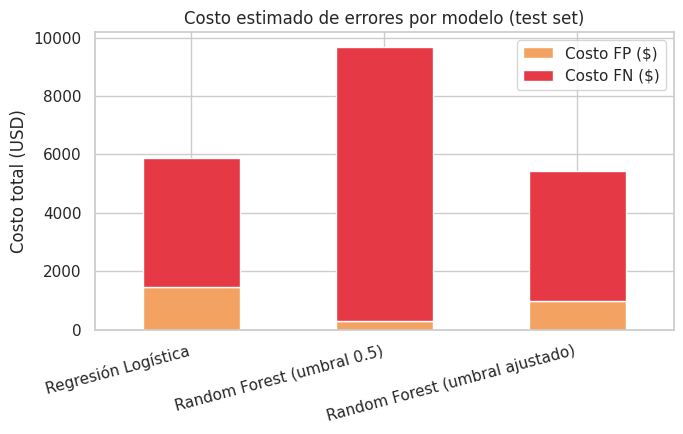

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
comparativo_costos[["Costo FP ($)", "Costo FN ($)"]].plot(
    kind="bar", stacked=True, ax=ax, color=["#f4a261", "#e63946"]
)
ax.set_title("Costo estimado de errores por modelo (test set)")
ax.set_ylabel("Costo total (USD)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.show()


Bajo este esquema de costos —donde perder una venta (**$45**) pesa mucho
más que regalar un descuento de más (**$5**)— **el modelo con menor Recall
sale más caro para el negocio, aunque tenga mejor Accuracy o Precision**.
Random Forest con su umbral por defecto (0.5) es, paradójicamente, el más
"costoso" de los tres, precisamente porque prioriza no dar falsas alarmas
por encima de no perder ventas. Ajustar su umbral de decisión reduce
significativamente este costo.


## 11. Interpretabilidad: ¿qué variables explican la compra?

Usamos la Regresión Logística para responder "¿por qué compra un cliente?", y comparamos con la importancia de variables de Random Forest.


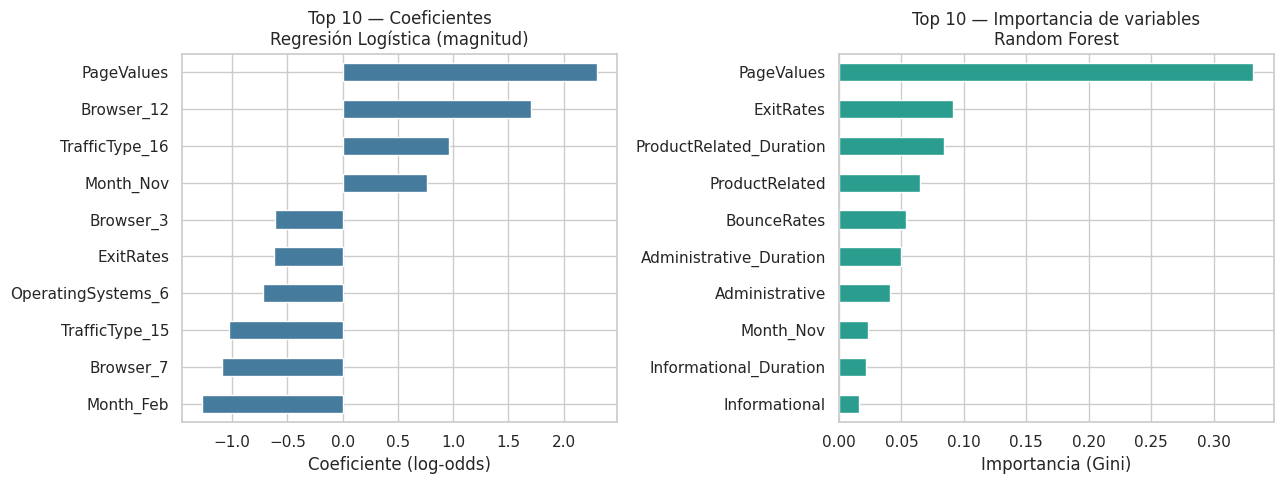

Variable más influyente (Regresión Logística): PageValues | coeficiente = 2.307
Variable más influyente (Random Forest):       PageValues | importancia = 0.332


In [17]:
ohe = log_reg.named_steps["preprocessor"].named_transformers_["cat"]
nombres_cat = ohe.get_feature_names_out(categorical_cols)
nombres_features = list(nombres_cat) + numerical_cols

coeficientes = pd.Series(
    log_reg.named_steps["classifier"].coef_[0], index=nombres_features
).sort_values(key=np.abs, ascending=False)

importancias = pd.Series(
    random_forest.named_steps["classifier"].feature_importances_,
    index=nombres_features,
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coeficientes.head(10).sort_values().plot(
    kind="barh", ax=axes[0], color="#457b9d"
)
axes[0].set_title("Top 10 — Coeficientes\nRegresión Logística (magnitud)")
axes[0].set_xlabel("Coeficiente (log-odds)")

importancias.head(10).sort_values().plot(
    kind="barh", ax=axes[1], color="#2a9d8f"
)
axes[1].set_title("Top 10 — Importancia de variables\nRandom Forest")
axes[1].set_xlabel("Importancia (Gini)")

plt.tight_layout()
plt.show()

print("Variable más influyente (Regresión Logística):",
      coeficientes.index[0], f"| coeficiente = {coeficientes.iloc[0]:.3f}")
print("Variable más influyente (Random Forest):      ",
      importancias.index[0], f"| importancia = {importancias.iloc[0]:.3f}")


**Ambos modelos coinciden: `PageValues` es la variable más influyente en la decisión de compra.**

`PageValues` es una métrica de Google Analytics: el valor promedio de las páginas visitadas antes de una conversión, funcionando como señal de "qué tan cerca está la sesión de comprar". Variables de duración como `ProductRelated_Duration` también aparecen relevantes en Random Forest, pero con menor peso — no es solo cuánto tiempo pasa el usuario, sino qué tan valiosas son las páginas que visita.


## 12. Reporte Ejecutivo — Conclusión para el Director de Marketing

### 1. ¿Qué modelo recomiendo para producción y por qué?

**Recomiendo desplegar Random Forest como motor de scoring en producción,
recalibrando su umbral de decisión (≈0.27 en vez de 0.50), y usar la
Regresión Logística como modelo complementario de explicabilidad.**

La razón no es el Accuracy (89.2% en Random Forest vs. 84.1% en Regresión
Logística) — como demostramos en la Sección 7, un modelo que nunca detecta
un solo comprador ya alcanza 84.5% de Accuracy, así que esta métrica por sí
sola es engañosa en un dataset tan desbalanceado (84.5% / 15.5%).

La razón real es doble:

- **Poder de discriminación de fondo:** Random Forest tiene un ROC-AUC
  superior (0.92 vs. 0.89), lo que significa que ordena mejor a los clientes
  por probabilidad de compra, independientemente del punto de corte que se
  use.
- **Costo de negocio:** al calibrar el umbral de Random Forest para igualar
  el Recall de la Regresión Logística (~74%, es decir, capturar 3 de cada 4
  compradores reales), su Precision resultante (≈59%) supera claramente a
  la de Regresión Logística (≈49%) en ese mismo nivel de Recall. Esto se
  traduce en **menos costo total estimado** en nuestro análisis de la
  Sección 10, porque reduce los Falsos Negativos (ventas perdidas, el error
  más caro) sin disparar tantos Falsos Positivos como el modelo lineal.

En otras palabras: Random Forest no es "mejor" simplemente porque tenga más
Accuracy, sino porque, una vez ajustado a la tolerancia al riesgo del
negocio (priorizar no perder ventas), ofrece el mejor balance costo-beneficio
de los dos modelos evaluados. El umbral exacto (0.27, 0.50 u otro) debe
revisarse periódicamente si cambian los costos reales de cupón/margen.

### 2. ¿Qué variable influye más en la compra, según el modelo explicable?

**`PageValues`** (el valor promedio de las páginas visitadas antes de una
conversión) es, por un margen amplio, la variable con mayor influencia sobre
la probabilidad de compra según la Regresión Logística — hallazgo que
Random Forest confirma de manera independiente. Recomendamos a Marketing:

- Priorizar la inversión en las páginas y flujos de navegación que
  históricamente generan `PageValues` altos (páginas de producto con alta
  tasa de conversión), en lugar de optimizar únicamente por tiempo de
  permanencia en el sitio.
- Usar `PageValues` en tiempo real como disparador de intervenciones: una
  sesión que empieza a acumular `PageValues` alto es una señal temprana de
  intención de compra fuerte, momento ideal para reforzar la conversión
  (ej. recordatorio de carrito, envío gratis) en vez de esperar señales
  tardías de abandono.
